In [1]:
import sqlite3
import pandas as pd
import numpy as np
from scipy import stats

conn = sqlite3.connect("../data/sales_project.db")

In [2]:
# Transactions of customers with the most customer service interactions

query = """
SELECT
    c.Customer_ID,
    COUNT(*) AS Customer_Service_Times,
    t.Transactions,
    t.Spent_Amount
FROM CS_Interaction_Records c

JOIN (
    SELECT
        Customer_ID,
        COUNT(*) AS transactions,
        SUM(Total_Price) AS Spent_Amount
    FROM Transaction_Records
    GROUP BY Customer_ID
) t 
    ON c.Customer_ID = t.Customer_ID

GROUP BY c.Customer_ID
ORDER BY Customer_Service_Times DESC
LIMIT 10;
"""

df = pd.read_sql_query(query, conn)
print(df)

   Customer_ID  Customer_Service_Times  transactions  Spent_Amount
0  Customer_22                       9             7           732
1  Customer_20                       8             8           703
2   Customer_7                       7            12          1219
3   Customer_4                       7             6           564
4   Customer_3                       7             6           803
5  Customer_21                       7             3           242
6  Customer_14                       7             6           495
7  Customer_13                       7             8           959
8  Customer_12                       7             6           489
9  Customer_11                       7             8           770


In [3]:
# Average spending of customers with/without escalation records

query = """
WITH escalation_date AS (
    SELECT Customer_ID, MIN(Interaction_Date) AS first_escalation
    FROM CS_Interaction_Records
    WHERE Interaction_Outcome = 'Escalated'
    GROUP BY Customer_ID
)
SELECT
    CASE WHEN t.Purchase_Date > e.first_escalation
        THEN 'After Escalation'
        ELSE 'Before Escalation'
    END AS period,
    COUNT(*)                        AS transaction_count,
    ROUND(AVG(t.Total_Price), 2)    AS avg_spending
FROM Transaction_Records t

JOIN escalation_date e
    ON t.Customer_ID = e.Customer_ID
    
GROUP BY period;
"""
df = pd.read_sql_query(query, conn)
print(df)

              period  transaction_count  avg_spending
0   After Escalation                110        106.33
1  Before Escalation                 76        105.45


In [4]:
# Extract the average spending of customers before and after their first escalation record

query = """
WITH escalation_date AS (
    SELECT Customer_ID, MIN(Interaction_Date) AS first_escalation
    FROM CS_Interaction_Records
    WHERE Interaction_Outcome = 'Escalated'
    GROUP BY Customer_ID
),
qualified_customers AS (
    SELECT e.Customer_ID
    FROM escalation_date e
    WHERE EXISTS (
        SELECT 1 FROM Transaction_Records t
        WHERE t.Customer_ID = e.Customer_ID
          AND t.Purchase_Date < e.first_escalation
    )
    AND EXISTS (
        SELECT 1 FROM Transaction_Records t
        WHERE t.Customer_ID = e.Customer_ID
          AND t.Purchase_Date > e.first_escalation
    )
)
SELECT
    t.Customer_ID,
    ROUND(AVG(
        CASE WHEN t.Purchase_Date < e.first_escalation 
            THEN t.Total_Price 
        END), 2
    ) AS avg_before,
    ROUND(AVG(
        CASE WHEN t.Purchase_Date > e.first_escalation 
            THEN t.Total_Price 
        END), 2
    ) AS avg_after
FROM Transaction_Records t

INNER JOIN escalation_date e 
    ON t.Customer_ID = e.Customer_ID

INNER JOIN qualified_customers q 
    ON t.Customer_ID = q.Customer_ID

GROUP BY t.Customer_ID
"""
df_raw = pd.read_sql_query(query, conn)
print(df_raw)

    Customer_ID  avg_before  avg_after
0    Customer_1      126.00     104.67
1   Customer_10      117.57     138.50
2   Customer_12       59.33     103.67
3   Customer_14       49.67     115.33
4   Customer_15      130.00     125.00
5   Customer_19       85.67     109.00
6    Customer_2       34.50      48.40
7   Customer_22       88.60     144.50
8   Customer_23       88.50     118.75
9   Customer_24       78.00      64.00
10  Customer_26      133.67      75.83
11  Customer_27       97.40     114.60
12  Customer_29      185.00     125.86
13   Customer_3      213.50      94.00
14   Customer_4       68.75     144.50
15   Customer_6       86.60     128.20
16   Customer_7       96.83     106.33
17   Customer_8      210.00     158.71


In [5]:
# Using the extracted data, perform paired t-test to examine if there is a significantly difference

t_stat, p_value = stats.ttest_rel(df_raw["avg_before"], df_raw["avg_after"])
print(f"n = {len(df_raw)} | t = {t_stat:.4f} | p = {p_value:.4f}")

n = 18 | t = -0.3274 | p = 0.7474


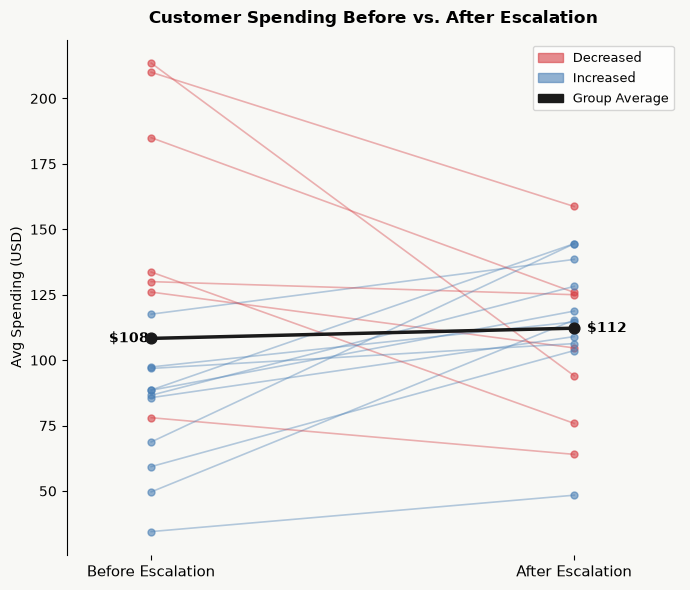

In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(7, 6))
fig.patch.set_facecolor("#F8F8F5")
ax.set_facecolor("#F8F8F5")

for _, row in df_raw.iterrows():
    color = "#D64045" if row["avg_after"] < row["avg_before"] else "#4A7FB5"
    ax.plot(
        [0, 1],
        [row["avg_before"], row["avg_after"]],
        color=color,
        alpha=0.4,
        linewidth=1.2,
    )
    ax.scatter(
        [0, 1], [row["avg_before"], row["avg_after"]], color=color, s=25, alpha=0.6
    )

# average
ax.plot(
    [0, 1],
    [df_raw["avg_before"].mean(), df_raw["avg_after"].mean()],
    color="#1A1A1A",
    linewidth=2.5,
    zorder=5,
)
ax.scatter(
    [0, 1],
    [df_raw["avg_before"].mean(), df_raw["avg_after"].mean()],
    color="#1A1A1A",
    s=60,
    zorder=6,
)

ax.annotate(
    f"${df_raw['avg_before'].mean():.0f}",
    xy=(0, df_raw["avg_before"].mean()),
    xytext=(-0.1, df_raw["avg_before"].mean()),
    va="center",
    fontweight="bold",
)
ax.annotate(
    f"${df_raw['avg_after'].mean():.0f}",
    xy=(1, df_raw["avg_after"].mean()),
    xytext=(1.03, df_raw["avg_after"].mean()),
    va="center",
    fontweight="bold",
)

ax.set_xticks([0, 1])
ax.set_xticklabels(["Before Escalation", "After Escalation"], fontsize=11)
ax.set_ylabel("Avg Spending (USD)")
ax.set_title("Customer Spending Before vs. After Escalation", fontweight="bold", pad=12)
ax.set_xlim(-0.2, 1.25)
ax.spines[["top", "right", "bottom"]].set_visible(False)

red = mpatches.Patch(color="#D64045", alpha=0.6, label="Decreased")
blue = mpatches.Patch(color="#4A7FB5", alpha=0.6, label="Increased")
black = mpatches.Patch(color="#1A1A1A", label="Group Average")
ax.legend(handles=[red, blue, black], fontsize=9)

plt.tight_layout()
plt.savefig(
    "../images/escalation_slopegraph.png",
    dpi=150,
    bbox_inches="tight",
    facecolor="#F8F8F5",
)
plt.show()

In [7]:
# Transactions, customer service interactions, marketing touchpoints, and web visits of the top 20 customers

query = """
    SELECT
    all_customers.Customer_ID,
    COALESCE(tx.tx_count,   0) AS transactions,
    COALESCE(cs.cs_count,   0) AS cs_interactions,
    COALESCE(mk.mk_count,   0) AS marketing_touchpoints,
    COALESCE(web.web_count, 0) AS web_visits
FROM (
    SELECT DISTINCT Customer_ID FROM Transaction_Records
    UNION
    SELECT DISTINCT Customer_ID FROM CS_Interaction_Records
    UNION
    SELECT DISTINCT Customer_ID FROM Marketing_Records
    UNION
    SELECT DISTINCT Customer_ID FROM Web_Interaction_Records
) all_customers
LEFT JOIN (SELECT Customer_ID, COUNT(*) AS tx_count  FROM Transaction_Records       GROUP BY Customer_ID) tx  ON all_customers.Customer_ID = tx.Customer_ID
LEFT JOIN (SELECT Customer_ID, COUNT(*) AS cs_count  FROM CS_Interaction_Records    GROUP BY Customer_ID) cs  ON all_customers.Customer_ID = cs.Customer_ID
LEFT JOIN (SELECT Customer_ID, COUNT(*) AS mk_count  FROM Marketing_Records         GROUP BY Customer_ID) mk  ON all_customers.Customer_ID = mk.Customer_ID
LEFT JOIN (SELECT Customer_ID, COUNT(*) AS web_count FROM Web_Interaction_Records   GROUP BY Customer_ID) web ON all_customers.Customer_ID = web.Customer_ID
ORDER BY transactions DESC
LIMIT 20;
"""

df = pd.read_sql_query(query, conn)
print(df)

    Customer_ID  transactions  cs_interactions  marketing_touchpoints  \
0    Customer_9            13                6                      7   
1    Customer_7            12                7                      7   
2   Customer_10            11                7                      4   
3   Customer_16            10                6                      7   
4   Customer_27            10                6                      4   
5    Customer_6            10                5                      6   
6   Customer_17             9                5                      8   
7   Customer_26             9                5                      5   
8   Customer_29             9                5                      8   
9    Customer_8             9                6                      6   
10  Customer_11             8                7                      6   
11  Customer_13             8                7                      4   
12  Customer_19             8                5     

In [8]:
# Average order value and total revenue by source/medium of the first visit

query = """
    WITH first_visit AS (
    SELECT Customer_ID, Source_Medium
    FROM Web_Interaction_Records
    WHERE Visit_Timestamp = (
        SELECT MIN(Visit_Timestamp)
        FROM Web_Interaction_Records w2
        WHERE w2.Customer_ID = Web_Interaction_Records.Customer_ID
    )
)
SELECT
    f.Source_Medium,
    COUNT(DISTINCT f.Customer_ID)   AS unique_visitors,
    ROUND(AVG(t.Total_Price), 2)    AS avg_order_value,
    ROUND(SUM(t.Total_Price), 2)    AS total_revenue
FROM Transaction_Records t
JOIN first_visit f ON t.Customer_ID = f.Customer_ID
GROUP BY f.Source_Medium
ORDER BY avg_order_value DESC

"""
df = pd.read_sql_query(query, conn)
print(df)

    Source_Medium  unique_visitors  avg_order_value  total_revenue
0          Social                6           117.29         4926.0
1        Referral                6           111.05         4886.0
2          Direct                2           107.53         1828.0
3     Paid Search                4           106.97         3851.0
4           Email                4           100.19         2605.0
5  Organic Search                7            89.75         4936.0
